# Step 3 – Clustering model creation and evaluation #


In this step I use the cleaned, standardized audio features from Step 2 to train KMeans clustering models. The goal is to explore different numbers of clusters, evaluate how well they separate the songs, and then choose a reasonable cluster count to use for later analysis and recommendations.

## Goals: ##

* Load the standardized feature dataset from Step 2 (`cleaned_features.csv`).
* Extract the topic score columns plus `age` as the input feature matrix.
* Run KMeans for a range of cluster counts and compare inertia and silhouette scores.
* Choose a reasonable number of clusters based on these diagnostics.
* Fit a final KMeans model and attach the resulting cluster labels back to the songs.

## Imports and data loading ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use("seaborn-v0_8-talk")

In [2]:
# Load cleaned features from Step 2
df = pd.read_csv("../data/cleaned_features.csv")
df.head()

,artist_name,track_name,genre,lyrics,len,dating,violence,world/life,night/time,shake the audience,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,mukesh,mohabbat bhi jhoothi,pop,hold time feel break feel untrue convince spea...,95,-0.391701,-0.305757,-0.699052,-0.507265,-0.413713,...,1.708762,-0.532716,-0.168459,-0.511362,-0.540584,-0.461616,1.385055,1.202722,sadness,2.176685
1,frankie laine,i believe,pop,believe drop rain fall grow believe darkest ni...,51,0.275514,-0.120872,1.872399,-0.501137,-0.396850,...,-0.688315,-0.528934,0.469964,-0.503873,1.827708,0.528490,-0.707263,-0.414650,world/life,2.176685
2,johnnie ray,cry,pop,sweetheart send letter goodbye secret feel bet...,24,-0.350224,-0.647063,-0.686440,-0.487853,-0.360291,...,1.589277,-0.520737,2.138148,-0.487639,-0.516330,-0.419054,-0.699057,2.713402,music,2.176685
3,pérez prado,patricia,pop,kiss lips want stroll charm mambo chacha merin...,54,0.518269,-0.653904,-0.693536,-0.498775,0.100400,...,-0.685902,-0.527477,-0.474436,0.893793,-0.529977,-0.443002,0.532652,-0.410961,romantic,2.176685
4,giorgos papadopoulos,apopse eida oneiro,pop,till darling till matter know till dream live ...,48,-0.377351,-0.655014,1.723380,-0.500549,-0.395231,...,-0.687714,-0.528571,-0.476045,-0.503154,-0.532193,0.109732,-0.334545,-0.413731,romantic,2.176685


## Reconstruct feature list ##

In [3]:
metadata_cols = ["artist_name", "track_name", "genre", "lyrics", "topic"]
metadata_cols = [c for c in metadata_cols if c in df.columns]

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

feature_cols = [
    c for c in numeric_cols
    if c not in metadata_cols
]

# Ensure len is not in the clustering features
if "len" in feature_cols:
    feature_cols.remove("len")

feature_cols

['dating',
 'violence',
 'world/life',
 'night/time',
 'shake the audience',
 'family/gospel',
 'romantic',
 'communication',
 'obscene',
 'music',
 'movement/places',
 'light/visual perceptions',
 'family/spiritual',
 'sadness',
 'feelings',
 'age']

To keep the feature definition consistent with Step 2, I reconstructed the feature list here instead of hardcoding column names. I remove metadata columns such as `artist_name`, `track_name`, `genre`, `lyrics`, and `topic`, and I'm also making sure `len` is not included as a clustering feature. The remaining columns are the standardized topic scores and `age`, which match the design choices from the previous step.

## Build the feature matrix ##

In [4]:
X = df[feature_cols].values
X.shape

(28362, 16)

## Evaluate KMeans for multiple k values ##

In [5]:
def evaluate_kmeans(X, k_values, random_state=42):
    inertias = []
    silhouettes = []

    for k in k_values:
        model = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = model.fit_predict(X)
        inertias.append(model.inertia_)
        # Silhouette only defined for k > 1
        silhouettes.append(silhouette_score(X, labels))

    return inertias, silhouettes

k_values = list(range(3, 11))
inertias, silhouettes = evaluate_kmeans(X, k_values)

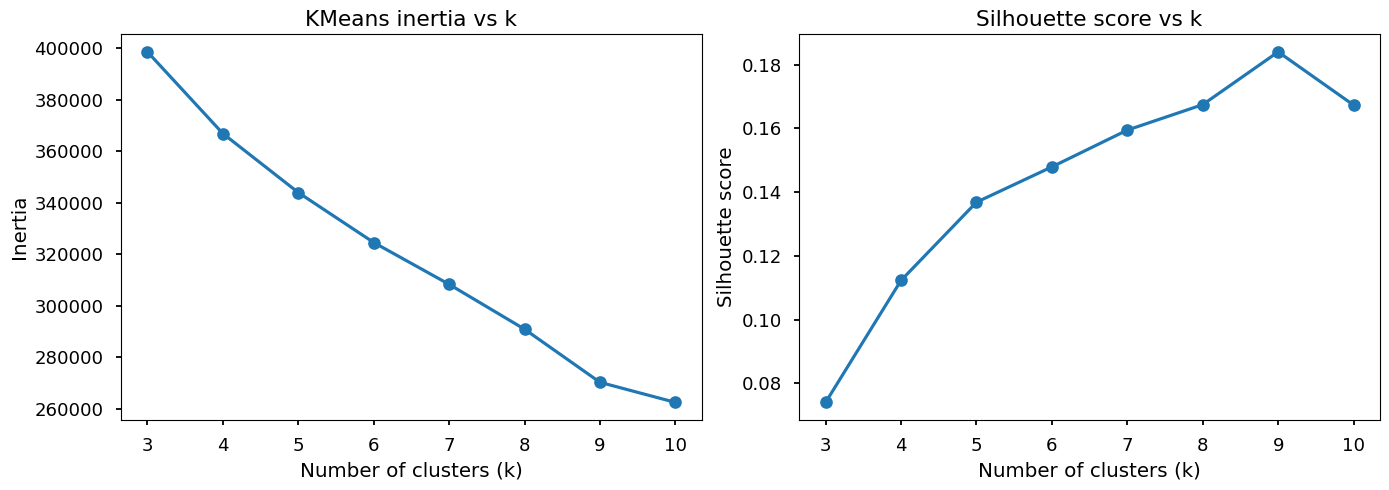

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, inertias, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("KMeans inertia vs k")

axes[1].plot(k_values, silhouettes, marker="o")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score vs k")

plt.tight_layout()
plt.show()

To choose a reasonable number of clusters, I ran KMeans for k values from 3 to 10 and looked at both inertia and silhouette score. The inertia curve drops steadily as k increases, which is expected because adding more clusters always makes it easier for the model to fit the data. The silhouette curve is more informative here: it climbs from k = 3 up through k = 9, reaches its highest value at k = 9, and then drops slightly at k = 10. Because inertia always decreases, I mainly use it to rule out very small k values, while the silhouette score gives me a concrete optimum. In this range, that optimum is at k = 9, so I treat k = 9 as the best balance between compact clusters and good separation.

Smaller k values (like 3–5) would underfit the topic–age structure by collapsing distinct themes together, while larger k values begin to split clusters in a way that hurts silhouette. Based on this trade-off, I move forward with 9 clusters as my main configuration for the final KMeans model.

## Fit final KMeans model and inspect cluster sizes ## 

In [9]:
best_k = 9

final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
cluster_labels = final_kmeans.fit_predict(X)

df["cluster"] = cluster_labels
df["cluster"].value_counts().sort_index()

cluster
0    4844
1    1944
2    1709
3    4330
4    5058
5    1895
6    2335
7     824
8    5423
Name: count, dtype: int64

Based on the inertia and silhouette plots, I set k = 9 for the final KMeans model and refit the algorithm on the standardized topic and age features. After attaching the resulting cluster labels back to the dataset, I checked how many songs fell into each group. The cluster sizes range from 824 songs in the smallest cluster to a little over 5,400 in the largest one, with several clusters in the 1,700–4,800 range. 

This distribution tells me that the model is using the feature space in a reasonably balanced way: there is some variation in size, which is expected, but no single cluster completely dominates the dataset and none are so tiny that they look like obvious outliers or mistakes. That makes me more confident that the nine clusters represent meaningful regions of the topic-and-age space that I can interpret and work with in the next step.

## Cluster summaries ##

In [12]:
cluster_summary = (
    df.groupby("cluster")[feature_cols]
    .mean()
    .round(3)
)

cluster_sizes = df["cluster"].value_counts().sort_index()
cluster_summary["count"] = cluster_sizes
cluster_summary

,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age,count
cluster,,,,,,,,,,,,,,,,,
0,-0.068,-0.422,1.818,-0.227,-0.037,-0.024,-0.171,0.052,-0.415,-0.258,-0.263,0.073,0.124,-0.356,-0.106,0.084,4844
1,0.223,-0.435,-0.411,3.063,0.047,0.024,-0.171,0.011,-0.362,-0.249,-0.145,-0.063,-0.159,-0.396,-0.050,0.094,1944
2,0.169,-0.517,-0.320,-0.170,-0.070,0.002,3.360,0.017,-0.458,-0.183,-0.308,0.091,-0.157,-0.311,-0.112,0.631,1709
3,0.022,-0.370,-0.457,-0.277,0.237,0.030,-0.324,-0.037,2.063,-0.302,-0.058,-0.228,-0.135,-0.568,-0.179,-0.449,4330
4,-0.143,1.796,-0.376,-0.233,-0.005,-0.015,-0.261,-0.001,-0.389,-0.297,-0.238,0.134,0.201,-0.419,-0.148,-0.255,5058
5,-0.220,0.079,-0.138,-0.213,-0.160,-0.041,-0.276,-0.423,0.042,-0.160,2.847,-0.227,-0.104,-0.273,-0.251,0.020,1895
6,0.060,-0.464,-0.424,-0.227,-0.067,0.108,-0.203,-0.120,-0.396,2.871,-0.082,0.173,0.096,-0.389,-0.144,0.419,2335
7,0.185,-0.395,-0.350,-0.141,0.062,0.027,-0.174,0.009,-0.306,-0.237,-0.136,-0.206,-0.122,-0.344,4.696,0.129,824
8,0.066,-0.451,-0.377,-0.210,-0.071,-0.034,-0.134,0.173,-0.438,-0.249,-0.287,0.023,-0.070,1.718,-0.135,0.082,5423


Looking at the cluster summary, a few clear patterns emerge. Each row represents one of the nine clusters, and the values are standardized, so numbers above zero mean “higher than the dataset average” for that feature and numbers below zero mean “lower than average.” For example, cluster 0 stands out for having a much higher average `world/life` score (around 1.8) and slightly higher `feelings`, while being lower than average on violence and obscene content. That suggests this group leans toward reflective, life-oriented themes rather than aggressive or explicit lyrics.

Several other clusters show similarly sharp profiles. Cluster 1 is the only group with a very strong positive score on `night/time` (around 3.1), which hints at a nightlife or evening-oriented theme, while most of its other topics sit below average. Cluster 2 has a very high `romantic` score (about 3.4) and is below average on many other themes, which makes it a natural candidate for a romance-focused cluster. In contrast, cluster 3 has a high `obscene` score (around 2.1) and generally lower values on softer themes, suggesting more explicit lyrical content. Cluster 4 is the only cluster with a very high `violence` score (around 1.8), so it likely groups songs with more aggressive or violent themes.

On the more specialized side, cluster 5 is characterized by a strong `movement/places` score, and cluster 6 has a high `music` score, which may indicate songs that explicitly talk about music or musical settings. Cluster 7 jumps out because it has a very high `sadness` score (around 4.7) and is small in size, which points to a niche cluster of strongly sad or emotional songs. Finally, cluster 8 has a high `family/spiritual` score and elevated sadness, which could represent more spiritual or faith-related songs with emotional content. Across all clusters, `age` also varies: some groups skew older (higher `age` values), while others look more recent, reinforcing the idea that time interacts with topic patterns in shaping these clusters.

In [15]:
df.to_csv("../data/trained_with_clusters.csv", index=False)

I saved the clustered dataset as `trained_with_clusters.csv` so I can reuse it in the reporting and recommendation step without having to rerun the clustering pipeline.
